# Data Processing

In [1]:
#import Lib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import dataset

df = pd.read_csv('/content/drive/MyDrive/new drive/DM Projrct/student-mat.csv',sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# **Data Cleaning**

In [3]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


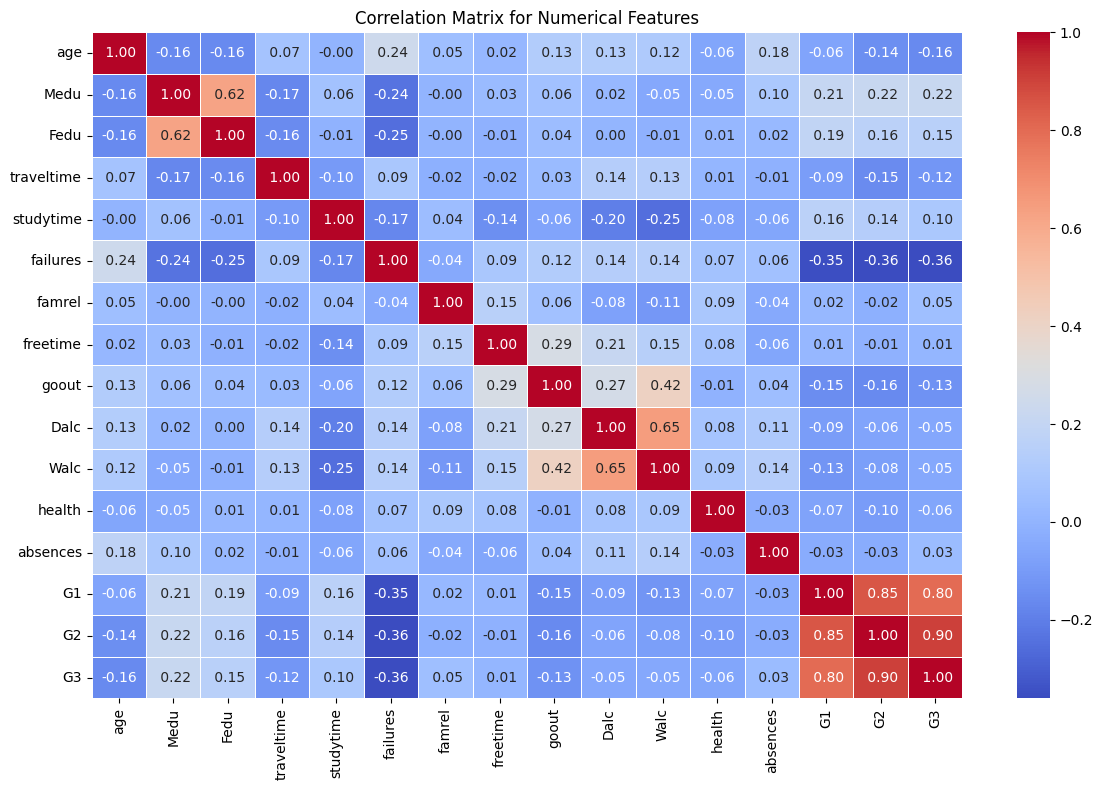

In [4]:
# correlation matrix
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=" .2f", linewidths=0.5)
plt.title('Correlation Matrix for Numerical Features')
plt.tight_layout()
plt.show()

# **Feature Engineering**

In [5]:
# Separate features and target
X = df.drop('G3', axis=1);
y = df['G3'];

def categorize_grade(g):
    if g <= 9:
        return 'Low'
    elif g <= 14:
        return 'Medium'
    else:
        return 'High'

# Create classified target
y_class = y.apply(categorize_grade)

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Encode categorical variables (Apply encoding BEFORE the split for classification)
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])

# One-hot encoding for nominal categorical variables (Apply encoding BEFORE the split for classification)
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

# Split the data for classification AFTER encoding
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)


from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
# Now fit the classifier with the encoded data
clf.fit(X_train_c, y_train_c)

y_pred_class = clf.predict(X_test_c)


In [6]:
# Create classified target
y_class = y.apply(categorize_grade)

# Re-split the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)


Confusion Matrix:
[[17  0  3]
 [ 0 25  2]
 [ 0  5 27]]

Classification Report:
               precision    recall  f1-score   support

        High       1.00      0.85      0.92        20
         Low       0.83      0.93      0.88        27
      Medium       0.84      0.84      0.84        32

    accuracy                           0.87        79
   macro avg       0.89      0.87      0.88        79
weighted avg       0.88      0.87      0.87        79



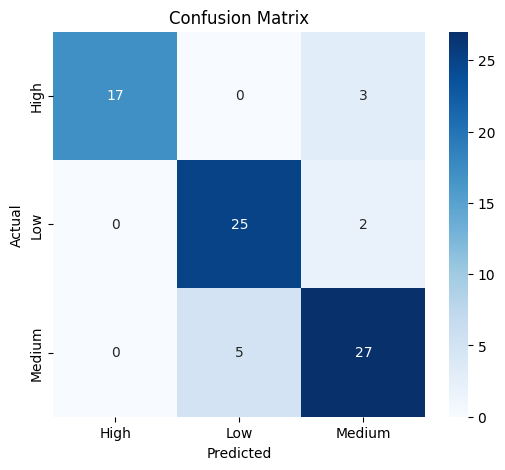

In [7]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_class)
print("Confusion Matrix:")
print(cm)

# Classification report: precision, recall, f1-score
report = classification_report(y_test_c, y_pred_class)
print("\nClassification Report:\n", report)

# Optional: Visualize confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [8]:
# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [9]:
# Encode categorical variables
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])

In [10]:
# Scale numeric features
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [11]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train Random Forest Regressor

In [12]:
# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [13]:
# Make predictions
y_pred = rf.predict(X_test)

In [14]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 3.75
R^2 Score: 0.82


In [15]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

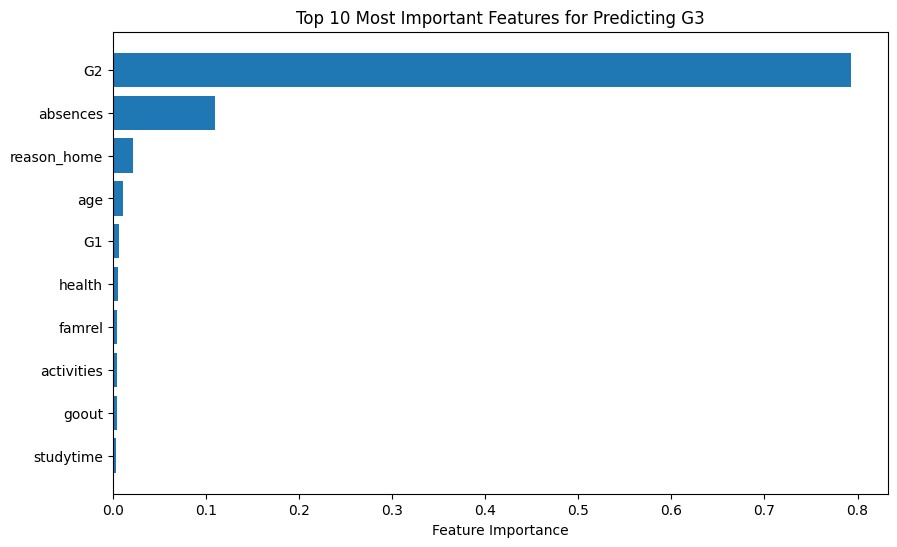

In [16]:
# Plot top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features for Predicting G3')
plt.gca().invert_yaxis()
plt.show()

In [17]:
# Print top 5 features
print("\nTop 5 Most Important Features:")
print(feature_importance.head())


Top 5 Most Important Features:
        Feature  Importance
27           G2    0.793061
25     absences    0.109794
36  reason_home    0.021152
2           age    0.011219
26           G1    0.006370


Train XGBoost Regressor

In [18]:
from xgboost import XGBRegressor

# Train XGBoost Regressor
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")
print(f"XGBoost R^2 Score: {r2_xgb:.2f}")

XGBoost Mean Squared Error: 4.63
XGBoost R^2 Score: 0.77


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R^2 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best R^2 Score: 0.9060232444566838


Install CatBoost Regressor

In [20]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.3 MB/s eta 0:00:00


Train CatBoost Regressor

In [21]:
from catboost import CatBoostRegressor

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Scale numeric features
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train CatBoost
catboost = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_state=42, verbose=0)
catboost.fit(X_train, y_train, cat_features=categorical_cols)

y_pred = catboost.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"CatBoost MSE: {mse:.2f}")
print(f"CatBoost R^2: {r2:.2f}")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': catboost.get_feature_importance()
}).sort_values(by='Importance', ascending=False)
print("\nTop 5 Features:")
print(feature_importance.head())

CatBoost MSE: 3.99
CatBoost R^2: 0.81

Top 5 Features:
     Feature  Importance
27        G2   51.437469
25  absences   16.885683
26        G1   11.133033
2        age    2.338205
24    health    1.910168


Train Support Vector Regressor

In [22]:
# Import SVR
from sklearn.svm import SVR

svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print(f"SVR Mean Squared Error: {mse_svr:.2f}")
print(f"SVR R^2 Score: {r2_svr:.2f}")

param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.2, 0.5],
    'kernel': ['rbf']
}

grid_search_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='r2', n_jobs=-1)
grid_search_svr.fit(X_train, y_train)

print("SVR Best Parameters:", grid_search_svr.best_params_)
print("SVR Best R^2 Score:", grid_search_svr.best_score_)

SVR Mean Squared Error: 6.53
SVR R^2 Score: 0.68
SVR Best Parameters: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
SVR Best R^2 Score: 0.7891777967474003


**Show Data Loss After Splitting**

In [23]:
from sklearn.model_selection import train_test_split

# Assume your DataFrame is already cleaned and stored in df
X = df.drop('G3', axis=1)
y = df['G3']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print dataset sizes
print(f"Total samples: {len(df)}")
print(f"Training set samples: {len(X_train)}")
print(f"Testing set samples: {len(X_test)}")
print(f"Total after split: {len(X_train) + len(X_test)}")

# Check for data loss
data_loss = len(df) - (len(X_train) + len(X_test))
print(f"Data loss after split: {data_loss} rows")


Total samples: 395
Training set samples: 316
Testing set samples: 79
Total after split: 395
Data loss after split: 0 rows


Predict Using XGBOOST

In [24]:
# Predict using XGBOOST

import numpy as np # Import numpy for select_dtypes include

manual_input_xgb = {
    'school': 'GP',
    'sex': 'F',
    'age': 17,
    'address': 'U',
    'famsize': 'GT3',
    'Pstatus': 'A',
    'Medu': 4,
    'Fedu': 4,
    'traveltime': 1,
    'studytime': 2,
    'failures': 0,
    'schoolsup': 'yes',
    'famsup': 'no',
    'paid': 'no',
    'activities': 'yes',
    'nursery': 'yes',
    'higher': 'yes',
    'internet': 'yes',
    'romantic': 'no',
    'famrel': 4,
    'freetime': 3,
    'goout': 4,
    'Dalc': 1,
    'Walc': 2,
    'health': 5,
    'absences': 3,
    'G1': 14,
    'G2': 15,
    'Mjob': 'teacher',
    'Fjob': 'services',
    'reason': 'home',
    'guardian': 'mother'
}

input_df_xgb = pd.DataFrame([manual_input_xgb])

# Re-create the one-hot encoded X to ensure column consistency
X_encoded = df.drop('G3', axis=1).copy()

# Identify categorical and numeric columns in the original dataframe
categorical_cols_orig = X_encoded.select_dtypes(include=['object']).columns
numeric_cols_orig = X_encoded.select_dtypes(include=['int64', 'float64']).columns

# Apply LabelEncoder to binary columns
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
le = LabelEncoder()
for col in binary_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col])
    input_df_xgb[col] = le.transform(input_df_xgb[col])
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
X_encoded = pd.get_dummies(X_encoded, columns=nominal_cols, drop_first=True)
input_df_xgb = pd.get_dummies(input_df_xgb, columns=nominal_cols, drop_first=True)
input_df_xgb = input_df_xgb.reindex(columns=X_encoded.columns, fill_value=0)
scaler = StandardScaler()
final_numeric_cols = X_encoded.select_dtypes(include=np.number).columns
original_numeric_cols_in_encoded = [col for col in final_numeric_cols if col in numeric_cols_orig]

scaler.fit(X_encoded[original_numeric_cols_in_encoded])
input_df_xgb[original_numeric_cols_in_encoded] = scaler.transform(input_df_xgb[original_numeric_cols_in_encoded])
predicted_g3_xgb = xgb.predict(input_df_xgb)
print(f"\n Predicted Final Grade (G3) using XGBoost: {predicted_g3_xgb[0]:.2f}")


 Predicted Final Grade (G3) using XGBoost: 15.49


Predict Using SVR

In [25]:
# Import SVR
from sklearn.svm import SVR
import numpy as np # Import numpy for select_dtypes include

manual_input_svr = {
    'school': 'GP',
    'sex': 'F',
    'age': 17,
    'address': 'U',
    'famsize': 'GT3',
    'Pstatus': 'A',
    'Medu': 4,
    'Fedu': 4,
    'traveltime': 1,
    'studytime': 2,
    'failures': 0,
    'schoolsup': 'yes',
    'famsup': 'no',
    'paid': 'no',
    'activities': 'yes',
    'nursery': 'yes',
    'higher': 'yes',
    'internet': 'yes',
    'romantic': 'no',
    'famrel': 4,
    'freetime': 3,
    'goout': 4,
    'Dalc': 1,
    'Walc': 2,
    'health': 5,
    'absences': 3,
    'G1': 14,
    'G2': 15,
    'Mjob': 'teacher',
    'Fjob': 'services',
    'reason': 'home',
    'guardian': 'mother'
}

# Make predictions
predicted_g3_svr = predict_grade(svr, manual_input_svr, scaler, le)

print(f"\nPredicted Final Grade (G3) using SVR: {predicted_g3_svr:.2f}")

NameError: name 'predict_grade' is not defined

Predict Using Random Forest

In [ ]:
# Manual prediction using Random Forest
import numpy as np # Import numpy for select_dtypes include

manual_input_rf = {
    'school': 'GP',
    'sex': 'F',
    'age': 17,
    'address': 'U',
    'famsize': 'GT3',
    'Pstatus': 'A',
    'Medu': 4,
    'Fedu': 4,
    'traveltime': 1,
    'studytime': 2,
    'failures': 0,
    'schoolsup': 'yes',
    'famsup': 'no',
    'paid': 'no',
    'activities': 'yes',
    'nursery': 'yes',
    'higher': 'yes',
    'internet': 'yes',
    'romantic': 'no',
    'famrel': 4,
    'freetime': 3,
    'goout': 4,
    'Dalc': 1,
    'Walc': 2,
    'health': 5,
    'absences': 3,
    'G1': 14,
    'G2': 15,
    'Mjob': 'teacher',
    'Fjob': 'services',
    'reason': 'home',
    'guardian': 'mother'
}

predicted_g3_rf = predict_grade(rf, manual_input_rf, scaler, le)
print(f"\nPredicted Final Grade (G3) using Random Forest: {predicted_g3_rf:.2f}")

# **Second Uppdate**

In [ ]:
def preprocess_input(df_input, full_df, scaler=None, fit_scaler=True):
    binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
                   'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
    nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

    le = LabelEncoder()
    for col in binary_cols:
        le.fit(full_df[col])
        df_input[col] = le.transform(df_input[col])

    df_input = pd.get_dummies(df_input, columns=nominal_cols, drop_first=True)

    # Align columns after one-hot encoding, before scaling
    full_df_encoded = pd.get_dummies(full_df.drop('G3', axis=1) if 'G3' in full_df.columns else full_df, columns=nominal_cols, drop_first=True)
    df_input = df_input.reindex(columns=full_df_encoded.columns, fill_value=0)


    numeric_cols = full_df_encoded.select_dtypes(include=np.number).columns
    if fit_scaler:
        scaler = StandardScaler()
        scaler.fit(full_df_encoded[numeric_cols])
    df_input[numeric_cols] = scaler.transform(df_input[numeric_cols])

    return df_input, scaler, le

In [ ]:
# Do this once at the beginning
X = df.drop('G3', axis=1)
y = df['G3']

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Encode categorical variables (Fit LabelEncoder on the full dataset)
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])

# One-hot encoding for nominal categorical variables (Apply encoding BEFORE the split)
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

# Scale numeric features (Fit StandardScaler on the full dataset)
scaler = StandardScaler()
# Re-identify numeric columns after one-hot encoding
numeric_cols_after_ohe = X.select_dtypes(include=np.number).columns
X[numeric_cols_after_ohe] = scaler.fit_transform(X[numeric_cols_after_ohe])


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from catboost import CatBoostRegressor

# Train CatBoost
catboost = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_state=42, verbose=0)
catboost.fit(X_train, y_train)

y_pred_catboost = catboost.predict(X_test)
mse_catboost = mean_squared_error(y_test, y_pred_catboost)
r2_catboost = r2_score(y_test, y_pred_catboost)

results = {
    "Model": ["Random Forest", "XGBoost", "CatBoost", "SVR"],
    "MSE": [mse, mse_xgb, mse_catboost, mse_svr],
    "R^2": [r2, r2_xgb, r2_catboost, r2_svr]
}
result_df = pd.DataFrame(results)
print(result_df)

In [ ]:
def predict_grade(model, manual_input_dict, scaler, le):
    input_df = pd.DataFrame([manual_input_dict])
    binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
                   'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
    for col in binary_cols:
      input_df[col] = le.transform(input_df[col])

    nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
    input_df = pd.get_dummies(input_df, columns=nominal_cols, drop_first=True)

    # Align columns after one-hot encoding
    # Use the columns from the training data (X_train) to reindex the input_df
    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)


    numeric_cols = input_df.select_dtypes(include=np.number).columns
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])


    return model.predict(input_df)[0]

**Newly Split**

In [ ]:
from sklearn.model_selection import train_test_split

# Assume `df` is the original DataFrame
X = df.drop("G3", axis=1)
y = df["G3"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Columns
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

# Fit encoder on training data
le = LabelEncoder()
for col in binary_cols:
    X_train_raw[col] = le.fit_transform(X_train_raw[col])
    X_test_raw[col] = le.transform(X_test_raw[col])  # transform only

# One-hot encoding (train and test separately, then align columns)
X_train = pd.get_dummies(X_train_raw, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=nominal_cols, drop_first=True)
X_train, X_test = X_train.align(X_train, join='right', axis=1, fill_value=0)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Split the data (raw, before any preprocessing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Count missing values in each dataset
missing_train = X_train.isnull().sum()
missing_test = X_test.isnull().sum()

# Total missing values
total_missing_train = missing_train.sum()
total_missing_test = missing_test.sum()

print("Missing values in training set per column:\n", missing_train[missing_train > 0])
print("\nMissing values in test set per column:\n", missing_test[missing_test > 0])
print(f"\nTotal missing values - Training set: {total_missing_train}")
print(f"Total missing values - Test set: {total_missing_test}")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Manual input data (same as provided in your code)
manual_input = {
    'school': 'GP',
    'sex': 'F',
    'age': 17,
    'address': 'U',
    'famsize': 'GT3',
    'Pstatus': 'A',
    'Medu': 4,
    'Fedu': 4,
    'traveltime': 1,
    'studytime': 2,
    'failures': 0,
    'schoolsup': 'yes',
    'famsup': 'no',
    'paid': 'no',
    'activities': 'yes',
    'nursery': 'yes',
    'higher': 'yes',
    'internet': 'yes',
    'romantic': 'no',
    'famrel': 4,
    'freetime': 3,
    'goout': 4,
    'Dalc': 1,
    'Walc': 2,
    'health': 5,
    'absences': 3,
    'G1': 14,
    'G2': 15,
    'Mjob': 'teacher',
    'Fjob': 'services',
    'reason': 'home',
    'guardian': 'mother'
}

# Preprocess the manual input using the provided preprocess_input function
input_df = pd.DataFrame([manual_input])
input_df_processed, scaler, le = preprocess_input(input_df, df, scaler, fit_scaler=False)

# Check for missing values in the preprocessed input data
print("\nMissing values in preprocessed input data:")
print(input_df_processed.isnull().sum())
print(f"Total missing values in preprocessed input: {input_df_processed.isnull().sum().sum()}")

# Predict using each model
predicted_g3_rf = rf.predict(input_df_processed)
predicted_g3_xgb = xgb.predict(input_df_processed)
predicted_g3_catboost = catboost.predict(input_df_processed)
predicted_g3_svr = svr.predict(input_df_processed)

# Print predictions
print(f"\nPredicted Final Grade (G3) using Random Forest: {predicted_g3_rf[0]:.2f}")
print(f"Predicted Final Grade (G3) using XGBoost: {predicted_g3_xgb[0]:.2f}")
print(f"Predicted Final Grade (G3) using CatBoost: {predicted_g3_catboost[0]:.2f}")
print(f"Predicted Final Grade (G3) using SVR: {predicted_g3_svr[0]:.2f}")

# Evaluate model performance on test set (MSE and R^2)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_catboost = catboost.predict(X_test)
y_pred_svr = svr.predict(X_test)

# Calculate MSE and R^2 for each model
results = {
    "Model": ["Random Forest", "XGBoost", "CatBoost", "SVR"],
    "MSE": [
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb),
        mean_squared_error(y_test, y_pred_catboost),
        mean_squared_error(y_test, y_pred_svr)
    ],
    "R^2": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_catboost),
        r2_score(y_test, y_pred_svr)
    ]
}

# Display results
result_df = pd.DataFrame(results)
print("\nModel Performance on Test Set:")
print(result_df.round(2))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split

# Step 1: Load and inspect the CSV file
try:
    df = pd.read_csv('/content/drive/MyDrive/new drive/DM Projrct/student-mat.csv', sep=';')
    print("Columns in df after loading:", df.columns.tolist())
    print("\nFirst few rows of df:\n", df.head())
except Exception as e:
    print(f"Error loading CSV: {e}")
    raise

# Verify that the expected columns exist
expected_cols = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
                 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
                 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet',
                 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                 'absences', 'G1', 'G2', 'G3']
missing_cols = [col for col in expected_cols if col not in df.columns]
if missing_cols:
    print(f"Warning: Missing expected columns: {missing_cols}")
    raise ValueError("CSV file does not contain the expected columns. Check the delimiter or file structure.")

# Step 2: Preprocess the DataFrame for training
X = df.drop('G3', axis=1)
y = df['G3']

# Define binary and nominal columns
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

# Label encode binary columns
le_dict = {}
for col in binary_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# One-hot encode nominal columns
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

# Scale numeric features
numeric_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train models (assuming models are not yet trained)
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# CatBoost
catboost = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_state=42, verbose=0)
catboost.fit(X_train, y_train)

# SVR
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

# Step 4: Preprocess manual input
manual_input = {
    'school': 'GP',
    'sex': 'F',
    'age': 17,
    'address': 'U',
    'famsize': 'GT3',
    'Pstatus': 'A',
    'Medu': 4,
    'Fedu': 4,
    'traveltime': 1,
    'studytime': 2,
    'failures': 0,
    'schoolsup': 'yes',
    'famsup': 'no',
    'paid': 'no',
    'activities': 'yes',
    'nursery': 'yes',
    'higher': 'yes',
    'internet': 'yes',
    'romantic': 'no',
    'famrel': 4,
    'freetime': 3,
    'goout': 4,
    'Dalc': 1,
    'Walc': 2,
    'health': 5,
    'absences': 3,
    'G1': 14,
    'G2': 15,
    'Mjob': 'teacher',
    'Fjob': 'services',
    'reason': 'home',
    'guardian': 'mother'
}

# Modified preprocess_input function
def preprocess_input(df_input, full_df, scaler, le_dict, fit_scaler=False):
    binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
                   'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
    nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

    # Check for missing columns
    missing_cols = [col for col in binary_cols + nominal_cols if col not in full_df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in full_df: {missing_cols}")

    missing_input_cols = [col for col in binary_cols + nominal_cols if col not in df_input.columns]
    if missing_input_cols:
        raise ValueError(f"Missing columns in input_df: {missing_input_cols}")

    # Copy input to avoid modifying original
    df_input = df_input.copy()
    full_df_encoded = full_df.drop('G3', axis=1) if 'G3' in full_df.columns else full_df.copy()

    # Label encode binary columns
    for col in binary_cols:
        le = le_dict.get(col)
        if le is None:
            raise ValueError(f"LabelEncoder not found for column: {col}")
        df_input[col] = le.transform(df_input[col])

    # One-hot encode nominal columns
    df_input = pd.get_dummies(df_input, columns=nominal_cols, drop_first=True)
    full_df_encoded = pd.get_dummies(full_df_encoded, columns=nominal_cols, drop_first=True)

    # Align columns
    df_input = df_input.reindex(columns=full_df_encoded.columns, fill_value=0)

    # Scale numeric features
    numeric_cols = full_df_encoded.select_dtypes(include=np.number).columns
    if fit_scaler:
        scaler = StandardScaler()
        scaler.fit(full_df_encoded[numeric_cols])


    return df_input, scaler

# Preprocess manual input
input_df = pd.DataFrame([manual_input])
try:
    input_df_processed, scaler = preprocess_input(input_df, df, scaler, le_dict, fit_scaler=False)
except ValueError as e:
    print(f"Error in preprocessing: {e}")
    raise

# Check for missing values in the preprocessed input data
print("\nMissing values in preprocessed input data:")
print(input_df_processed.isnull().sum())
print(f"Total missing values in preprocessed input: {input_df_processed.isnull().sum().sum()}")

# Step 5: Predict using each model
try:
    predicted_g3_rf = rf.predict(input_df_processed)
    predicted_g3_xgb = xgb.predict(input_df_processed)
    predicted_g3_catboost = catboost.predict(input_df_processed)
    predicted_g3_svr = svr.predict(input_df_processed)

    # Print predictions
    print(f"\nPredicted Final Grade (G3) using Random Forest: {predicted_g3_rf[0]:.2f}")
    print(f"Predicted Final Grade (G3) using XGBoost: {predicted_g3_xgb[0]:.2f}")
    print(f"Predicted Final Grade (G3) using CatBoost: {predicted_g3_catboost[0]:.2f}")
    print(f"Predicted Final Grade (G3) using SVR: {predicted_g3_svr[0]:.2f}")
except Exception as e:
    print(f"Error during prediction: {e}")
    raise

# Step 6: Evaluate model performance on test set (MSE and R^2)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_catboost = catboost.predict(X_test)
y_pred_svr = svr.predict(X_test)

# Calculate MSE and R^2 for each model
results = {
    "Model": ["Random Forest", "XGBoost", "CatBoost", "SVR"],
    "MSE": [
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb),
        mean_squared_error(y_test, y_pred_catboost),
        mean_squared_error(y_test, y_pred_svr)
    ],
    "R^2": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_catboost),
        r2_score(y_test, y_pred_svr)
    ]
}

# Display results
result_df = pd.DataFrame(results)
print("\nModel Performance on Test Set:")
print(result_df.round(2))

# Step 7: Check missing values in test set
print("\nMissing values in test set (X_test):")
print(X_test.isnull().sum())
print(f"Total missing values in test set: {X_test.isnull().sum().sum()}")